In [ ]:
# Importing libraries
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge
from sklearn.linear_model import Lasso
from sklearn.linear_model import ElasticNet
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier

from sklearn.model_selection import train_test_split
from sklearn.model_selection import KFold
from sklearn.model_selection import cross_val_score

from sklearn.metrics import mean_squared_error, mean_absolute_error, balanced_accuracy_score, confusion_matrix, classification_report
from sklearn.metrics import explained_variance_score
from sklearn.metrics import r2_score

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import Normalizer
from sklearn.preprocessing import RobustScaler

from sklearn.pipeline import make_pipeline

from sklearn.decomposition import PCA

warnings.filterwarnings("ignore")

###Description of the variables in the base DataFrame

VARIABLE | DESCRIPTION | TYPE  
---------|-------------|-----  
**FECHA_CORTE** | Data cutoff date | Numeric
**UBIGEO** | Geographical Location Code denoted as 'DDppdd' (Department, Province, District) | Alphanumeric  
**YY** | Year, año de registro | Numeric  
**MM** | Month, mes de registro | Numeric  
**DY** | Day, día de registro | Numeric  
**HH** | Hour, hora promedio del registro | Numeric  
**TT** | Air Temperature 2 meters (temperatura del aire a 2 metros) - [°C] | Numeric  
**HR** | Relative Humidity (Humedad Relativa) - [%] | Numeric  
**RR** | Precipitation (precipitación) - [mm] | Numeric  
**PP** | Atmospheric pressure (presión atmosférica) - [hPa] | Numeric  
**FF** | Wind speed (velocidad del aire) - [m/s] | Numeric  
**DD** | Wind direction (dirección del aire) - [degrees] | Numeric  


In [ ]:
# Reading the base dataset
df_base = pd.read_csv('IGP_EstacionEMA_2018-2024_Dataset.csv')
# The columns FECHA_CORTE and UBIGEO are removed because they are constant
df_base.drop(columns=["FECHA_CORTE","UBIGEO"],inplace=True)
df_base.head()

,YY,MM,DY,HH,TT,HR,RR,PP,FF,DD
0,2018,1,1,0,7.66098,89.51500,1.778,687.40333,2.97943,145.64165
1,2018,1,1,1,7.73552,90.29500,0.254,686.94167,1.70000,284.01833
2,2018,1,1,2,7.57108,91.00500,0.254,686.67667,1.65667,63.06462
3,2018,1,1,3,7.52045,89.73167,0.000,686.50000,1.13227,34.77467
4,2018,1,1,4,7.13343,88.88167,0.508,686.60333,0.64763,72.41817


### Description of variables in the auxiliary DataFrame of different wave irradiances

VARIABLE | DESCRIPTION | TYPE
---------|-------------|-----
**FECHA_CORTE**	| Data cutoff date |	Numeric
**UBIGEO**	| Geographical Location Code denoted as 'DDppdd' (Department, Province, District) | 	Alphanumeric
**year** |	Year, año de registro |	Numeric
**month** |	Month, mes de registro |	Numeric
**day** |	Day, dia de registro |	Numeric
**hour** | Hour, hora promedio del registro	| Numeric
**incide_LW_rad** |	Incident longwave irradiance (irradiancia incidente de onda larga) W m^{-2} |	Numeric
**emitte_LW_rad** | 	Emitted longwave irradiance (irradiancia emitida de onda larga) W m^{-2}	| Numeric
**direct_SW_rad** |	Direct shortwave irradiance (irradiancia directa de onda corta) W m^{-2}	| Numeric
**global_SW_rad** |	Global shortwave irrandiance (irradiancia glocal de onda corta) W m^{-2}	| Numeric
**diffus_SW_rad** |	Diffuse shortwave irradiance (irradiancia difusa de onda corta) W m^{-2}	| Numeric
**reflec_SW_rad** |	Reflected shortwave irradiance (irradiancia reflejada de onda corta) W m^{-2}	| Numeric

In [ ]:
df_aux1 = pd.read_csv('IGP_EstacionBSRN_2021-2023_Dataset_0.csv')
df_aux1.drop(columns=["FECHA_CORTE","UBIGEO"],inplace=True)
df_aux1.head()

,year,month,day,hour,incide_LW_rad,emitte_LW_rad,direct_SW_rad,global_SW_rad,diffus_SW_rad,reflec_SW_rad
0,2021,1,1,0,352.05167,367.13500,-0.25327,0.0,0.0,0.0
1,2021,1,1,1,352.87167,364.62333,-0.20893,0.0,0.0,0.0
2,2021,1,1,2,345.94833,359.72500,-0.22720,0.0,0.0,0.0
3,2021,1,1,3,343.00833,357.59000,-0.15992,0.0,0.0,0.0
4,2021,1,1,4,341.39167,357.58333,-0.11268,0.0,0.0,0.0


**The columns of the base DataFrame are renamed to match the date names in the auxiliary DataFrame.**

This is done for two reasons:
1. The variables will be understandable without relying on the data dictionary.
2. A merge can be applied without issues because the column names match.

In [ ]:
df_base.rename(columns={'YY': 'year', 'MM': 'month', 'DY': 'day', 'HH': 'hour'}, inplace=True)

In [ ]:
df_final = df_base.merge(df_aux1, on=['year', 'month', 'day', 'hour'], how='inner')
print(df_final.shape)
df_final.head()

(26280, 16)


,year,month,day,hour,TT,HR,RR,PP,FF,DD,incide_LW_rad,emitte_LW_rad,direct_SW_rad,global_SW_rad,diffus_SW_rad,reflec_SW_rad
0,2021,1,1,0,10.21567,89.11500,0.000,686.42667,0.76495,137.41667,352.05167,367.13500,-0.25327,0.0,0.0,0.0
1,2021,1,1,1,9.46817,92.15333,2.540,686.20333,1.08187,212.86167,352.87167,364.62333,-0.20893,0.0,0.0,0.0
2,2021,1,1,2,8.41033,94.19000,2.794,686.09167,1.27178,124.28170,345.94833,359.72500,-0.22720,0.0,0.0,0.0
3,2021,1,1,3,7.83418,94.81167,2.286,686.16167,0.72635,137.59570,343.00833,357.59000,-0.15992,0.0,0.0,0.0
4,2021,1,1,4,7.82893,94.77833,1.270,686.47667,0.99590,304.42042,341.39167,357.58333,-0.11268,0.0,0.0,0.0


In [ ]:
df_final=df_final.dropna()

In [ ]:
df_final.isnull().sum()

,0
year,0
month,0
day,0
hour,0
TT,0
HR,0
RR,0
PP,0
FF,0
DD,0


In [ ]:
df1=df_final.drop(columns=['RR'])

In [ ]:
df1

,year,month,day,hour,TT,HR,PP,FF,DD,incide_LW_rad,emitte_LW_rad,direct_SW_rad,global_SW_rad,diffus_SW_rad,reflec_SW_rad
0,2021,1,1,0,10.21567,89.11500,686.42667,0.76495,137.41667,352.05167,367.13500,-0.25327,0.0,0.0,0.0
1,2021,1,1,1,9.46817,92.15333,686.20333,1.08187,212.86167,352.87167,364.62333,-0.20893,0.0,0.0,0.0
2,2021,1,1,2,8.41033,94.19000,686.09167,1.27178,124.28170,345.94833,359.72500,-0.22720,0.0,0.0,0.0
3,2021,1,1,3,7.83418,94.81167,686.16167,0.72635,137.59570,343.00833,357.59000,-0.15992,0.0,0.0,0.0
4,2021,1,1,4,7.82893,94.77833,686.47667,0.99590,304.42042,341.39167,357.58333,-0.11268,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
25916,2023,12,16,20,9.50950,88.70500,687.55833,2.70477,124.55708,330.86333,362.72333,-0.10637,0.0,0.0,0.0
25917,2023,12,16,21,9.25217,88.74000,687.82000,2.54373,116.06547,318.85000,360.35833,-0.12065,0.0,0.0,0.0
25918,2023,12,16,22,8.88700,90.57000,688.28000,1.38287,141.80000,296.66167,355.66500,-0.10048,0.0,0.0,0.0
25919,2023,12,16,23,7.44867,95.69667,687.91667,2.05465,270.97500,277.11833,349.23000,-0.40282,0.0,0.0,0.0


In [ ]:
shift=1
df1=df1.iloc[:-1*shift]
df1

,year,month,day,hour,TT,HR,PP,FF,DD,incide_LW_rad,emitte_LW_rad,direct_SW_rad,global_SW_rad,diffus_SW_rad,reflec_SW_rad
0,2021,1,1,0,10.21567,89.11500,686.42667,0.76495,137.41667,352.05167,367.13500,-0.25327,0.0,0.0,0.0
1,2021,1,1,1,9.46817,92.15333,686.20333,1.08187,212.86167,352.87167,364.62333,-0.20893,0.0,0.0,0.0
2,2021,1,1,2,8.41033,94.19000,686.09167,1.27178,124.28170,345.94833,359.72500,-0.22720,0.0,0.0,0.0
3,2021,1,1,3,7.83418,94.81167,686.16167,0.72635,137.59570,343.00833,357.59000,-0.15992,0.0,0.0,0.0
4,2021,1,1,4,7.82893,94.77833,686.47667,0.99590,304.42042,341.39167,357.58333,-0.11268,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
25915,2023,12,16,19,9.07850,90.48000,687.37500,3.22438,274.75333,343.59667,362.73333,-0.13072,0.0,0.0,0.0
25916,2023,12,16,20,9.50950,88.70500,687.55833,2.70477,124.55708,330.86333,362.72333,-0.10637,0.0,0.0,0.0
25917,2023,12,16,21,9.25217,88.74000,687.82000,2.54373,116.06547,318.85000,360.35833,-0.12065,0.0,0.0,0.0
25918,2023,12,16,22,8.88700,90.57000,688.28000,1.38287,141.80000,296.66167,355.66500,-0.10048,0.0,0.0,0.0


In [ ]:
df2=df_final['RR']
df2

,RR
0,0.000
1,2.540
2,2.794
3,2.286
4,1.270
...,...
25916,0.000
25917,0.000
25918,0.000
25919,0.000


In [ ]:
df2=df2.drop(df2.index[0:shift])
df2

,RR
1,2.540
2,2.794
3,2.286
4,1.270
5,0.000
...,...
25916,0.000
25917,0.000
25918,0.000
25919,0.000


In [ ]:
df_total = pd.concat([df1.reset_index(drop=True), df2.reset_index(drop=True)], axis=1)
df_total

,year,month,day,hour,TT,HR,PP,FF,DD,incide_LW_rad,emitte_LW_rad,direct_SW_rad,global_SW_rad,diffus_SW_rad,reflec_SW_rad,RR
0,2021,1,1,0,10.21567,89.11500,686.42667,0.76495,137.41667,352.05167,367.13500,-0.25327,0.0,0.0,0.0,2.540
1,2021,1,1,1,9.46817,92.15333,686.20333,1.08187,212.86167,352.87167,364.62333,-0.20893,0.0,0.0,0.0,2.794
2,2021,1,1,2,8.41033,94.19000,686.09167,1.27178,124.28170,345.94833,359.72500,-0.22720,0.0,0.0,0.0,2.286
3,2021,1,1,3,7.83418,94.81167,686.16167,0.72635,137.59570,343.00833,357.59000,-0.15992,0.0,0.0,0.0,1.270
4,2021,1,1,4,7.82893,94.77833,686.47667,0.99590,304.42042,341.39167,357.58333,-0.11268,0.0,0.0,0.0,0.000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19785,2023,12,16,19,9.07850,90.48000,687.37500,3.22438,274.75333,343.59667,362.73333,-0.13072,0.0,0.0,0.0,0.000
19786,2023,12,16,20,9.50950,88.70500,687.55833,2.70477,124.55708,330.86333,362.72333,-0.10637,0.0,0.0,0.0,0.000
19787,2023,12,16,21,9.25217,88.74000,687.82000,2.54373,116.06547,318.85000,360.35833,-0.12065,0.0,0.0,0.0,0.000
19788,2023,12,16,22,8.88700,90.57000,688.28000,1.38287,141.80000,296.66167,355.66500,-0.10048,0.0,0.0,0.0,0.000


In [ ]:
df_total['rain_exists'] = df_total['RR'].apply(lambda x: 0 if x <= 0.0 else 1)
print(df_total.groupby('month')['rain_exists'].value_counts())
df_total.drop(columns='rain_exists', inplace=True)

selected_months = [12, 1, 2, 3]
df_total = df_total[df_total['month'].isin(selected_months)]

print(df_total.shape)

df_total.drop(columns=['year','day','month','hour'],inplace=True)

month  rain_exists
1      0              1689
       1               207
2      0              1202
       1               129
3      0              1617
       1               226
4      0              1439
       1                92
5      0              1429
       1                69
6      0              1653
       1                23
7      0              1687
       1                 3
8      0              1554
       1                21
9      0              1644
       1                55
10     0              1621
       1                86
11     0              1606
       1               125
12     0              1463
       1               150
Name: count, dtype: int64
(6683, 16)


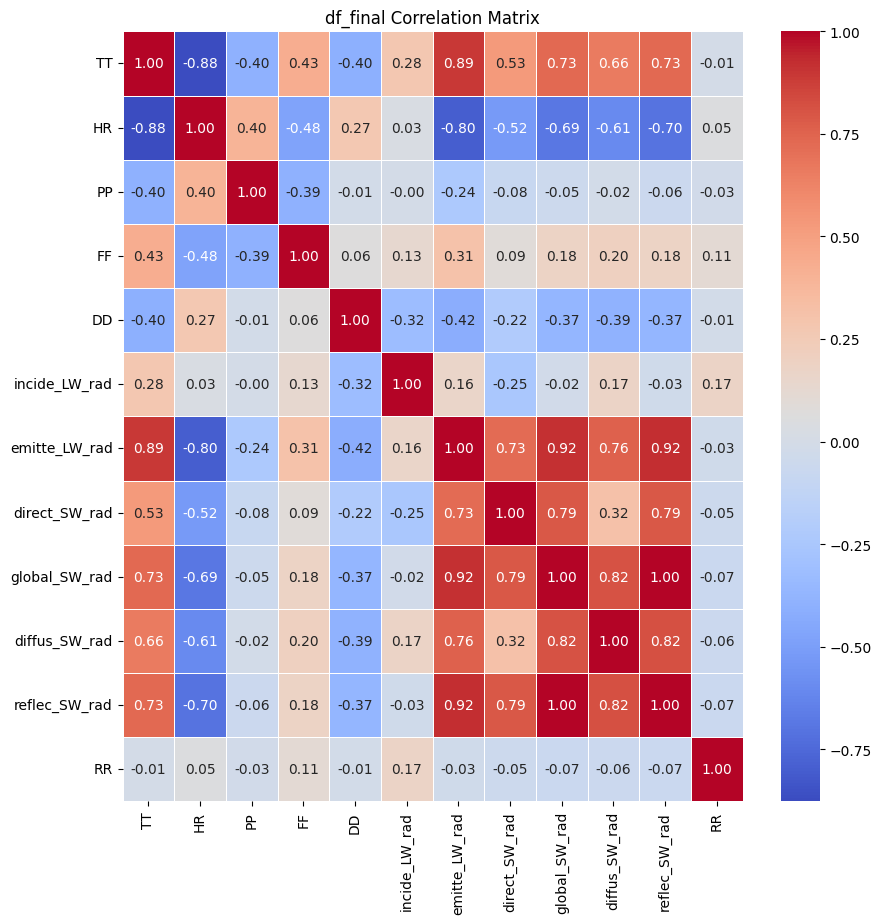

In [ ]:
# Calculate the correlation matrix of df_final
corr_matrix = df_total.corr()

# Plot the heatmap
plt.figure(figsize=(10, 10))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', linewidths=0.5)

# Show the plot
plt.title('df_final Correlation Matrix')
plt.show()

In [ ]:
X=df_total.drop(columns=['RR'])
y=df_total['RR']

In [ ]:
columns_drop=['reflec_SW_rad','diffus_SW_rad','global_SW_rad']

In [ ]:
df_total.drop(columns=columns_drop, inplace=True)

In [ ]:
df_total

,TT,HR,PP,FF,DD,incide_LW_rad,emitte_LW_rad,direct_SW_rad,RR
0,10.21567,89.11500,686.42667,0.76495,137.41667,352.05167,367.13500,-0.25327,2.540
1,9.46817,92.15333,686.20333,1.08187,212.86167,352.87167,364.62333,-0.20893,2.794
2,8.41033,94.19000,686.09167,1.27178,124.28170,345.94833,359.72500,-0.22720,2.286
3,7.83418,94.81167,686.16167,0.72635,137.59570,343.00833,357.59000,-0.15992,1.270
4,7.82893,94.77833,686.47667,0.99590,304.42042,341.39167,357.58333,-0.11268,0.000
...,...,...,...,...,...,...,...,...,...
19785,9.07850,90.48000,687.37500,3.22438,274.75333,343.59667,362.73333,-0.13072,0.000
19786,9.50950,88.70500,687.55833,2.70477,124.55708,330.86333,362.72333,-0.10637,0.000
19787,9.25217,88.74000,687.82000,2.54373,116.06547,318.85000,360.35833,-0.12065,0.000
19788,8.88700,90.57000,688.28000,1.38287,141.80000,296.66167,355.66500,-0.10048,0.000


#Model with Balanced Classes using SMOTE

To address the class imbalance in the dataset, the SMOTE (Synthetic Minority Over-sampling Technique) method is applied. SMOTE generates synthetic samples of the minority class (days with moderate or heavy rainfall) by interpolating between similar observations in the feature space. Importantly, SMOTE is applied only after splitting the dataset into training and test sets, and it is applied exclusively to the training data. This ensures that synthetic information does not “leak” into the test set, preserving its role as an unbiased evaluation of the model’s performance.

With this procedure, the classifier is trained on a more balanced dataset, which:

1. Reduces bias toward the majority class (days without rain or with light rain).

2. Increases the model’s ability to learn patterns associated with significant rainfall.

3. Improves critical metrics such as recall and balanced accuracy.

For simplification, rainfall intensity is defined into two levels:

Class 0 → No rain or light rain.

Class 1 → Moderate or heavy rain.

In [ ]:
print(df_total['RR'].value_counts())
bins = [0, 2.5, np.inf]
labels = [0, 1]
df_total['rain_intensity'] = pd.cut(df_total['RR'], bins=bins, labels=labels, right=False)
df_total.drop(columns='RR', inplace=True)

RR
0.000     5971
0.254      313
0.508      111
0.762       59
1.016       51
1.270       37
1.524       20
1.778       20
2.032       17
2.794       13
2.286       12
2.540       12
3.302       10
3.810        6
3.556        5
3.048        5
4.826        4
4.064        2
5.080        2
4.572        2
7.112        1
6.096        1
10.414       1
6.604        1
5.842        1
8.128        1
5.588        1
6.350        1
7.874        1
4.318        1
6.858        1
Name: count, dtype: int64


In [ ]:
print(df_total['rain_intensity'].value_counts())

rain_intensity
0    6611
1      72
Name: count, dtype: int64


A balanced training set is prepared for a binary classification problem on the variable rain_intensity, which exhibits class imbalance. First, the dataset is split into training and test sets before applying any balancing technique. Then, a manual undersampling of the majority class is performed to obtain a more balanced dataset. Finally, SMOTE (Synthetic Minority Over-sampling Technique) is applied to generate synthetic samples of the minority class, while avoiding the excessive creation of artificial data by reducing the dominance of the majority class beforehand.

In [ ]:
from collections import Counter

X = df_total.drop('rain_intensity', axis=1)
y = df_total['rain_intensity']

x_train, x_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.25, random_state=42)

# Training dataset copy for the case where SMOTE is not applied
x_train_no_smote = x_train.copy()
y_train_no_smote = y_train.copy()

print("Train data distribution:")
print(Counter(y_train))
print("Test data distribution:")
print(Counter(y_test))

Train data distribution:
Counter({0: 4958, 1: 54})
Test data distribution:
Counter({0: 1653, 1: 18})


In [ ]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(sampling_strategy='not majority', random_state=42)

x_train, y_train = smote.fit_resample(x_train, y_train)

print("Train data distribution after SMOTE:")
print(Counter(y_train))

Train data distribution after SMOTE:
Counter({0: 4958, 1: 4958})


In [ ]:
algos = []
algos.append(('LogReg', LogisticRegression( solver='liblinear', class_weight='balanced')))
algos.append(('5NN', KNeighborsClassifier( n_neighbors=5)))
algos.append(('10NN', KNeighborsClassifier( n_neighbors=10)))
algos.append(('CART_none', DecisionTreeClassifier(max_depth=None, class_weight='balanced')))
algos.append(('CART_20', DecisionTreeClassifier(max_depth=20, class_weight='balanced')))
algos.append(('XGBClassifier', XGBClassifier()))

In [ ]:
results = []
names = []

seed = 7
kfold = KFold(n_splits=10, random_state=seed, shuffle= True)

for algoname, algo in algos:
    cv_results = cross_val_score(algo, x_train, y_train, cv=kfold, scoring='balanced_accuracy')
    results.append(cv_results)
    names.append(algoname)
    print("{}: {} ({})".format(algoname, cv_results.mean(), cv_results.std()))

LogReg: 0.8075185686724898 (0.017183096835195723)
5NN: 0.9248540991752625 (0.010890286620265177)
10NN: 0.9131005420806216 (0.010313567853719157)
CART_none: 0.9553179811864396 (0.006170177910919886)
CART_20: 0.9535185312637224 (0.005915714847079806)
XGBClassifier: 0.979906116809264 (0.00249190779679747)


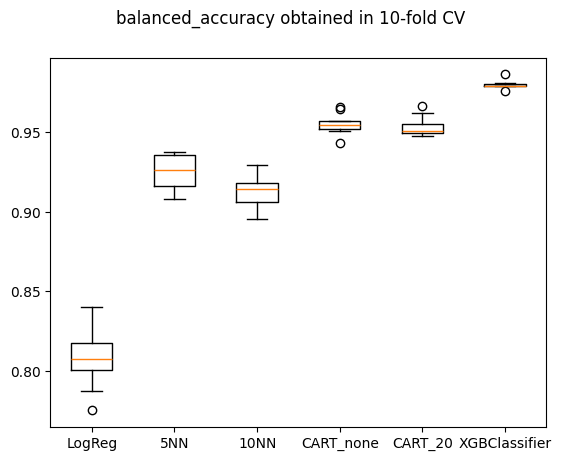

In [ ]:
fig = plt.figure()
fig.suptitle('balanced_accuracy obtained in 10-fold CV')
ax = fig.add_subplot(111)
plt.boxplot(results)
ax.set_xticklabels(names)
plt.show()

The LogisticRegression algorithm was selected because it achieves the highest balanced accuracy. Additionally, it provides the best prediction for cases of moderate or heavy rainfall (recall = 0.83), which is the most critical outcome to predict. Missing actual moderate or heavy rainfall events (false negatives) carries a higher cost than issuing a false alarm, making it a priority to maximize recall for this class.

In [ ]:
model = LogisticRegression(solver='liblinear', class_weight='balanced')
model.fit(x_train, y_train)

y_predicted = model.predict(x_test)
print("Balanced Accuracy score:", balanced_accuracy_score(y_test, y_predicted))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_predicted))

print("\nClassification Report on the Validation Set: \n")
print(classification_report(y_test, y_predicted))

Balanced Accuracy score: 0.8050514216575922

Confusion Matrix:
[[1284  369]
 [   3   15]]

Classification Report on the Validation Set: 

              precision    recall  f1-score   support

           0       1.00      0.78      0.87      1653
           1       0.04      0.83      0.07        18

    accuracy                           0.78      1671
   macro avg       0.52      0.81      0.47      1671
weighted avg       0.99      0.78      0.86      1671



A model using the XGBClassifier algorithm was trained for comparison with the previous model. It showed lower balanced accuracy, and therefore the first model was chosen.

In [ ]:
model = XGBClassifier()
model.fit(x_train, y_train)

y_predicted = model.predict(x_test)
print("Balanced Accuracy score:", balanced_accuracy_score(y_test, y_predicted))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_predicted))

print("\nClassification Report on the Validation Set: \n")
print(classification_report(y_test, y_predicted))

Balanced Accuracy score: 0.6189251865295422

Confusion Matrix:
[[1587   66]
 [  13    5]]

Classification Report on the Validation Set: 

              precision    recall  f1-score   support

           0       0.99      0.96      0.98      1653
           1       0.07      0.28      0.11        18

    accuracy                           0.95      1671
   macro avg       0.53      0.62      0.54      1671
weighted avg       0.98      0.95      0.97      1671



#Neural Network Classifier using SMOTE
A feedforward neural network was implemented. The model was trained using the training set after applying SMOTE to address class imbalance. The architecture consists of three hidden layers (100, 30, 15) with ReLU activation functions, and the output layer uses a sigmoid (or softmax) activation to predict class probabilities. The Adam optimizer was selected for efficient training, and early stopping was applied to reduce overfitting.

This model was chosen because neural networks can capture complex, non-linear relationships between meteorological features, potentially improving prediction performance compared to simpler classifiers such as logistic regression.

In [ ]:
from sklearn.neural_network import MLPClassifier

mlp = MLPClassifier(hidden_layer_sizes=(100,30,15), activation='relu', solver='adam', max_iter=1000, random_state=42)
mlp.fit(x_train, y_train)

y_pred = mlp.predict(x_test)

print("Balanced Accuracy score:", balanced_accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nClassification Report on the Validation Set: \n")
print(classification_report(y_test, y_pred))

Balanced Accuracy score: 0.8675640250050414

Confusion Matrix:
[[1307  346]
 [   1   17]]

Classification Report on the Validation Set: 

              precision    recall  f1-score   support

           0       1.00      0.79      0.88      1653
           1       0.05      0.94      0.09        18

    accuracy                           0.79      1671
   macro avg       0.52      0.87      0.49      1671
weighted avg       0.99      0.79      0.87      1671



The neural network classifier achieved a balanced accuracy score of 0.87, which is an improvement over previous models. The recall for the minority class (rain days) reached 0.94, indicating that the model successfully detects nearly all days with rainfall. However, the precision for the minority class is very low (0.05), meaning the model generates many false positives. This trade-off is also reflected in the macro F1-score (0.49), which shows that while the model performs strongly on the majority class, performance on the minority class remains weak.

#If SMOTE is not applied, ...
The model will be trained on an imbalanced dataset, which may cause it to be biased toward the majority class and perform poorly in detecting the minority class.

In [ ]:
x_train = x_train_no_smote.copy()
y_train = y_train_no_smote.copy()

print("Train data distribution without SMOTE:")
print(Counter(y_train))


Train data distribution without SMOTE:
Counter({0: 4958, 1: 54})


In [ ]:
algos = []
algos.append(('LogReg', LogisticRegression( solver='liblinear', class_weight='balanced')))
algos.append(('5NN', KNeighborsClassifier( n_neighbors=5)))
algos.append(('10NN', KNeighborsClassifier( n_neighbors=10)))
algos.append(('CART_none', DecisionTreeClassifier(max_depth=None, class_weight='balanced')))
algos.append(('CART_20', DecisionTreeClassifier(max_depth=20, class_weight='balanced')))
algos.append(('XGBClassifier', XGBClassifier()))

In [ ]:
results = []
names = []

seed = 7
kfold = KFold(n_splits=10, random_state=seed, shuffle= True)

for algoname, algo in algos:
    cv_results = cross_val_score(algo, x_train, y_train, cv=kfold, scoring='balanced_accuracy')
    results.append(cv_results)
    names.append(algoname)
    print("{}: {} ({})".format(algoname, cv_results.mean(), cv_results.std()))

LogReg: 0.7873335851998781 (0.09388518698733056)
5NN: 0.49989898989898995 (0.000303030303030305)
10NN: 0.5 (0.0)
CART_none: 0.5857402278379898 (0.1460858886517832)
CART_20: 0.6267552646234374 (0.14105879735750532)
XGBClassifier: 0.5193406324669483 (0.041042529974799555)


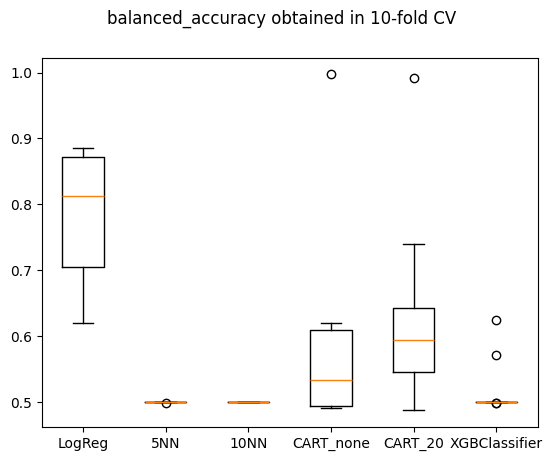

In [ ]:
fig = plt.figure()
fig.suptitle('balanced_accuracy obtained in 10-fold CV')
ax = fig.add_subplot(111)
plt.boxplot(results)
ax.set_xticklabels(names)
plt.show()

In [ ]:
model = LogisticRegression(solver='liblinear', class_weight='balanced')
model.fit(x_train, y_train)

y_predicted = model.predict(x_test)
print("Balanced Accuracy score:", balanced_accuracy_score(y_test, y_predicted))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_predicted))

print("\nClassification Report on the Validation Set: \n")
print(classification_report(y_test, y_predicted))

Balanced Accuracy score: 0.7944646098003629

Confusion Matrix:
[[1249  404]
 [   3   15]]

Classification Report on the Validation Set: 

              precision    recall  f1-score   support

           0       1.00      0.76      0.86      1653
           1       0.04      0.83      0.07        18

    accuracy                           0.76      1671
   macro avg       0.52      0.79      0.46      1671
weighted avg       0.99      0.76      0.85      1671



For LogisticRegressor, SMOTE achieves a slight improvement in both balanced accuracy and overall accuracy (0.78 vs 0.76), but it does not address the issue of the very low precision for the minority class. The model is still generating too many false positives.


In [ ]:
model = DecisionTreeClassifier(max_depth=20, class_weight='balanced')
model.fit(x_train, y_train)

y_predicted = model.predict(x_test)
print("Balanced Accuracy score:", balanced_accuracy_score(y_test, y_predicted))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_predicted))

print("\nClassification Report on the Validation Set: \n")
print(classification_report(y_test, y_predicted))

Balanced Accuracy score: 0.573049001814882

Confusion Matrix:
[[1619   34]
 [  15    3]]

Classification Report on the Validation Set: 

              precision    recall  f1-score   support

           0       0.99      0.98      0.99      1653
           1       0.08      0.17      0.11        18

    accuracy                           0.97      1671
   macro avg       0.54      0.57      0.55      1671
weighted avg       0.98      0.97      0.98      1671



Neural Network Classifier

In [ ]:
mlp = MLPClassifier(hidden_layer_sizes=(100,30,15), activation='relu', solver='adam', max_iter=1000, random_state=42)
mlp.fit(x_train, y_train)

y_pred = mlp.predict(x_test)

print("Balanced Accuracy score:", balanced_accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nClassification Report on the Validation Set: \n")
print(classification_report(y_test, y_pred))

Balanced Accuracy score: 0.5

Confusion Matrix:
[[1653    0]
 [  18    0]]

Classification Report on the Validation Set: 

              precision    recall  f1-score   support

           0       0.99      1.00      0.99      1653
           1       0.00      0.00      0.00        18

    accuracy                           0.99      1671
   macro avg       0.49      0.50      0.50      1671
weighted avg       0.98      0.99      0.98      1671

